# ✈️ Flight Price Prediction — Complete Ensemble ML Pipeline

## Dataset: Indian Domestic Flights (Data_Train.xlsx)

> **Target Variable:** `Price` (₹ INR — continuous regression task)

> <b>NOTE:</b>Used Codex to define heading and prepare the documented notebook(for Github),Rest all logic curated ,tested and implemented by me.


In [43]:
# ─────────────────────────────────────────────────────────────
# SECTION 1: IMPORTS & ENVIRONMENT SETUP
# ─────────────────────────────────────────────────────────────

# Standard libraries
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Sklearn – preprocessing & utilities
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                             r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance

# Sklearn – individual base models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Sklearn – ENSEMBLE models (the main focus)
from sklearn.ensemble import (
    RandomForestRegressor,       # Bagging
    ExtraTreesRegressor,         # Bagging variant
    BaggingRegressor,            # Generic Bagging wrapper
    GradientBoostingRegressor,   # Boosting
    AdaBoostRegressor,           # Boosting
    VotingRegressor,             # Voting
    StackingRegressor            # Stacking
)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print("✅ All imports successful!")

✅ All imports successful!


---
## 📁 Section 1 — Data Loading & Overview
We load the dataset and take an initial look at its shape, data types, and a few sample rows.

In [44]:
# Load the Excel dataset
df = pd.read_excel('Data_Train.xlsx')

print(f"Dataset Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Memory Usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

df.head(5)

Dataset Shape : 10,683 rows  ×  11 columns
Memory Usage  : 6390.2 KB


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [45]:
# Quick schema overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [46]:
# Statistical summary of numeric columns
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


---
## 🔍 Section 2 — Exploratory Data Analysis (EDA)
### 2.1 Missing Values

In [47]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print(" No missing values found!")
else:
    print(missing_df)
    print("\nDropping rows with missing values (only 1-2 rows affected)…")
    df.dropna(inplace=True)
    print(f"Dataset shape after dropping NaN: {df.shape}")

             Missing Count  Missing %
Route                    1       0.01
Total_Stops              1       0.01

Dropping rows with missing values (only 1-2 rows affected)…
Dataset shape after dropping NaN: (10682, 11)


### 2.2 Target Variable — Price Distribution

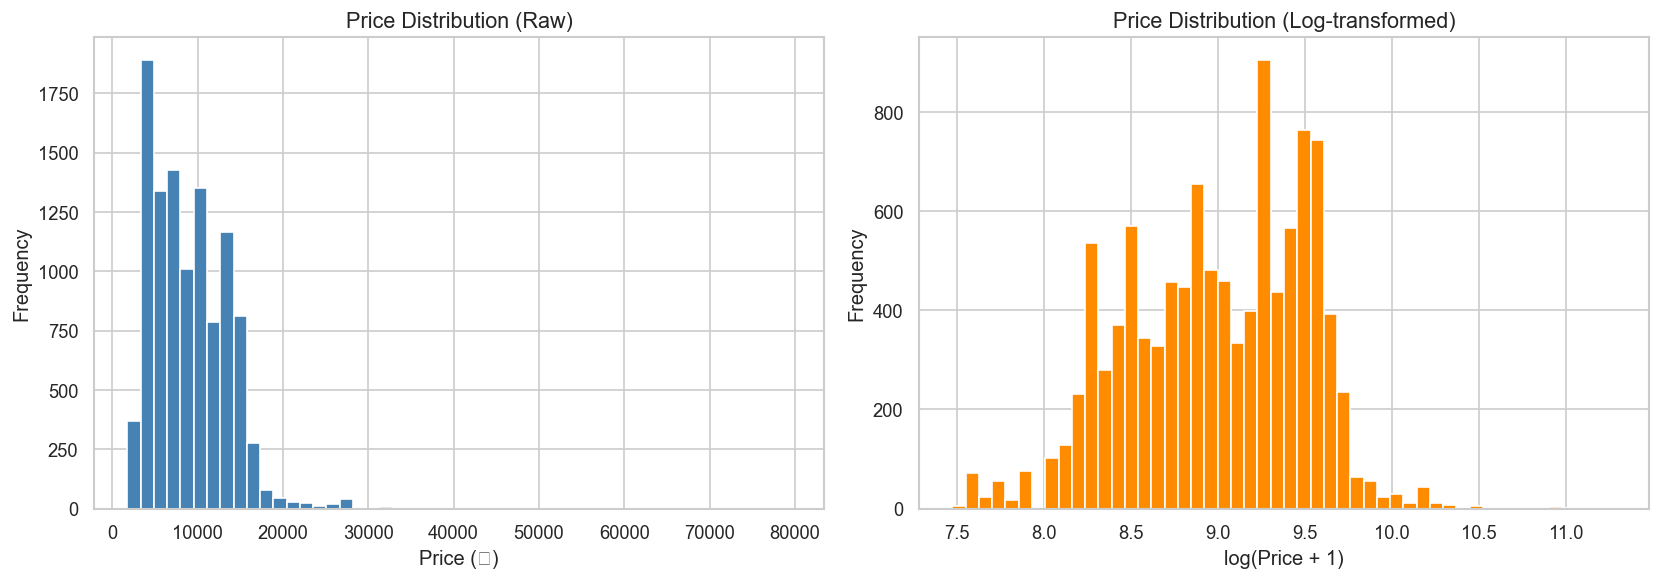

Skewness (raw)          : 1.812
Skewness (log-transform): -0.255

💡 Right-skewed distribution — the log-transform is more symmetric.


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Frequency')

# Log distribution
axes[1].hist(np.log1p(df['Price']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Price Distribution (Log-transformed)', fontsize=13)
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness (raw)          : {df['Price'].skew():.3f}")
print(f"Skewness (log-transform): {np.log1p(df['Price']).skew():.3f}")
print("\n💡 Right-skewed distribution — the log-transform is more symmetric.")

### 2.3 Categorical Feature Analysis

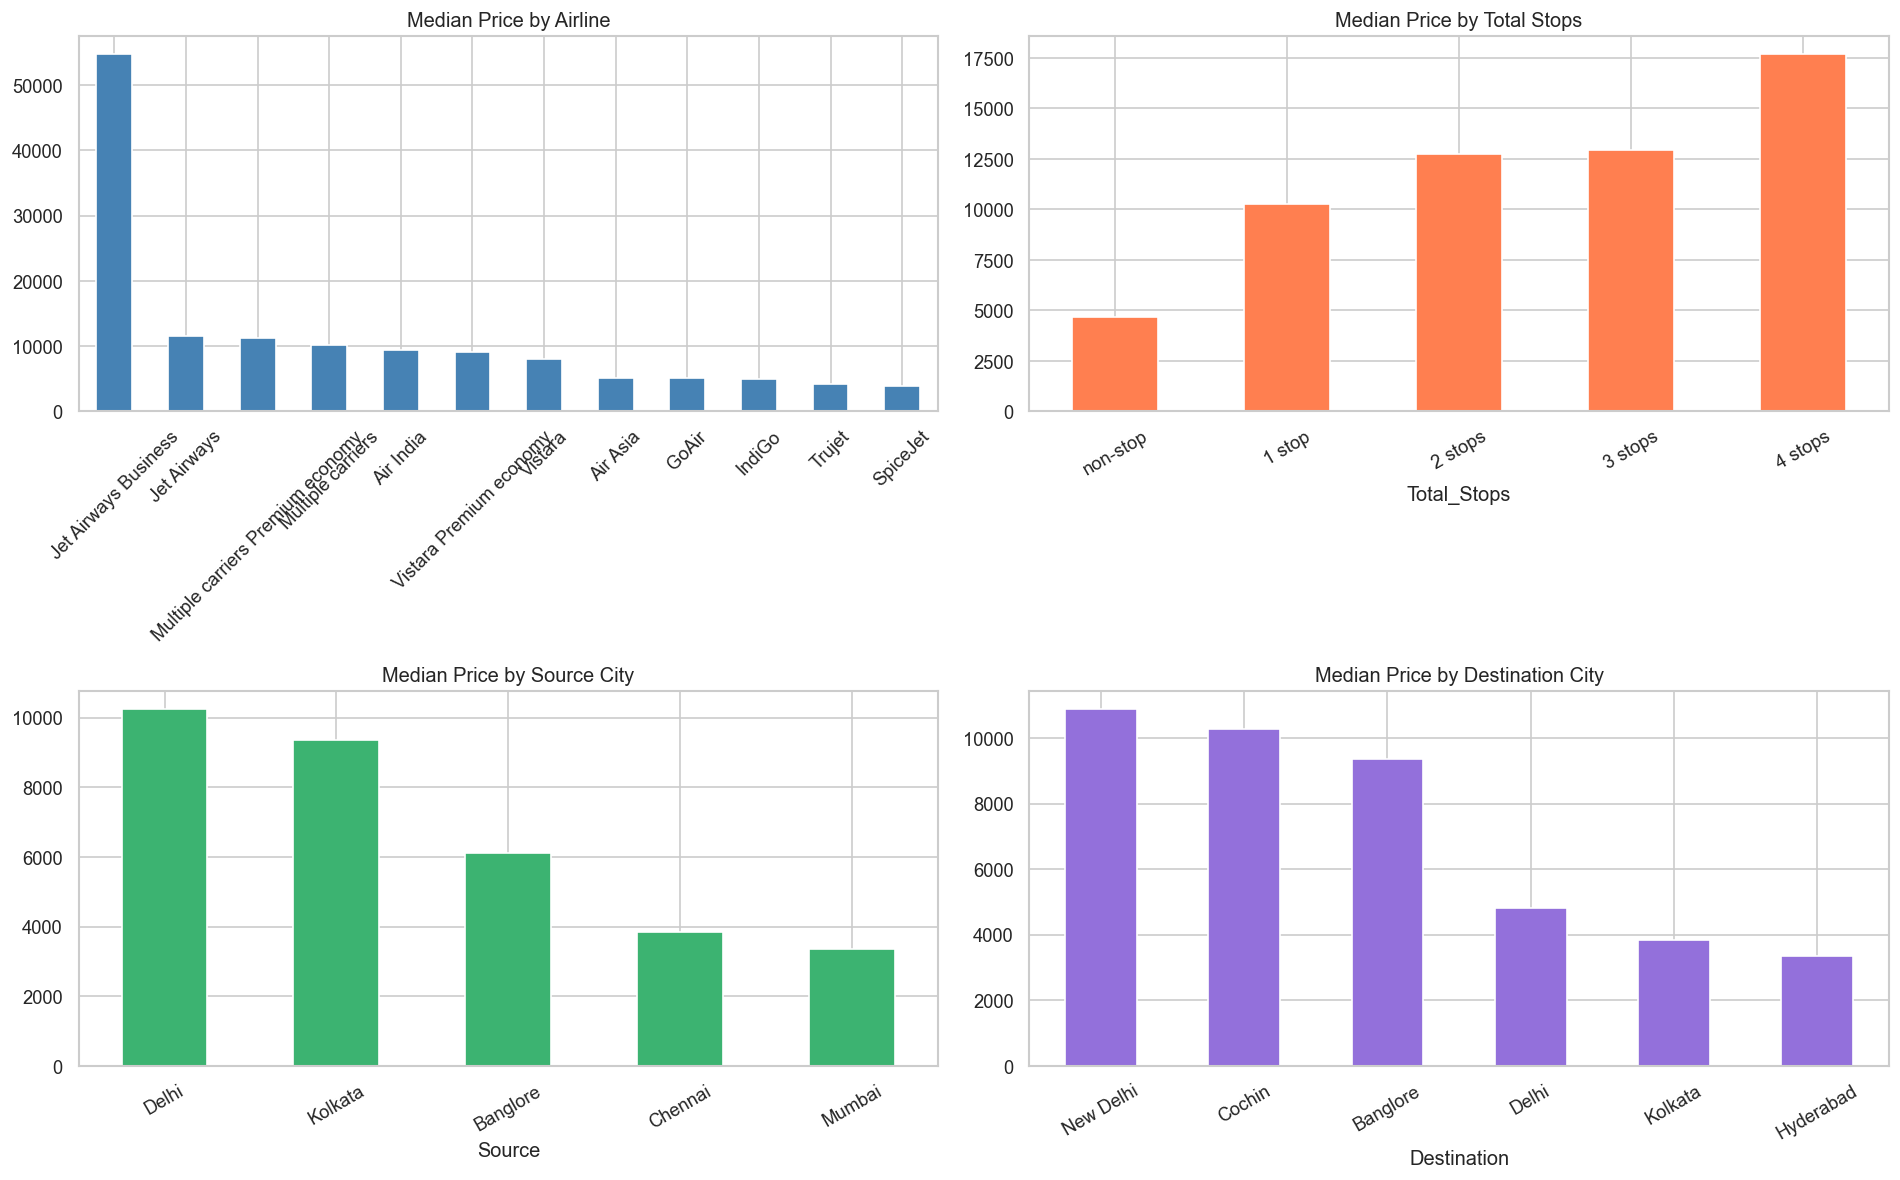

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Airline
airline_price = df.groupby('Airline')['Price'].median().sort_values(ascending=False)
airline_price.plot(kind='bar', ax=axes[0][0], color='steelblue', edgecolor='white')
axes[0][0].set_title('Median Price by Airline')
axes[0][0].set_xlabel('')
axes[0][0].tick_params(axis='x', rotation=45)

# Total Stops
stop_order = ['non-stop', '1 stop', '2 stops', '3 stops', '4 stops']
stop_price = df.groupby('Total_Stops')['Price'].median().reindex(stop_order, fill_value=0)
stop_price.plot(kind='bar', ax=axes[0][1], color='coral', edgecolor='white')
axes[0][1].set_title('Median Price by Total Stops')
axes[0][1].tick_params(axis='x', rotation=30)

# Source
src_price = df.groupby('Source')['Price'].median().sort_values(ascending=False)
src_price.plot(kind='bar', ax=axes[1][0], color='mediumseagreen', edgecolor='white')
axes[1][0].set_title('Median Price by Source City')
axes[1][0].tick_params(axis='x', rotation=30)

# Destination
dst_price = df.groupby('Destination')['Price'].median().sort_values(ascending=False)
dst_price.plot(kind='bar', ax=axes[1][1], color='mediumpurple', edgecolor='white')
axes[1][1].set_title('Median Price by Destination City')
axes[1][1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.4 Temporal Patterns

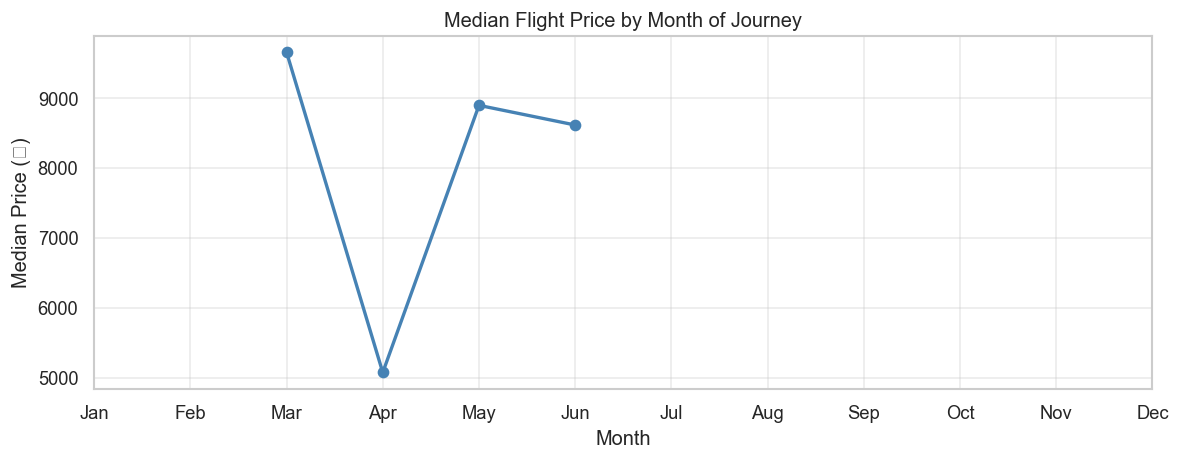

In [50]:
# Parse date to extract journey month
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
df['Journey_Month'] = df['Date_of_Journey'].dt.month
df['Journey_Day']   = df['Date_of_Journey'].dt.day
df['Journey_Weekday'] = df['Date_of_Journey'].dt.dayofweek   # 0=Mon

month_price = df.groupby('Journey_Month')['Price'].median()

plt.figure(figsize=(10, 4))
month_price.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Median Flight Price by Month of Journey')
plt.xlabel('Month')
plt.ylabel('Median Price (₹)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## ⚙️ Section 3 — Feature Engineering
We extract structured numeric/categorical features from raw string columns.

| Raw Column | Engineered Features |
|---|---|
| `Date_of_Journey` | Journey_Month, Journey_Day, Journey_Weekday |
| `Dep_Time` | Dep_Hour, Dep_Minute |
| `Arrival_Time` | Arrival_Hour, Arrival_Minute |
| `Duration` | Duration_Hours, Duration_Minutes → Duration_Total_Min |
| `Total_Stops` | Stops (ordinal integer) |
| `Airline`, `Source`, `Destination` | Label Encoded |

In [51]:
# ── 3.1  Date features  ──────────────────────────────────────
# Already extracted Journey_Month, Journey_Day, Journey_Weekday above

# ── 3.2  Departure time  ─────────────────────────────────────
df['Dep_Hour']   = pd.to_datetime(df['Dep_Time'],   format='%H:%M').dt.hour
df['Dep_Minute'] = pd.to_datetime(df['Dep_Time'],   format='%H:%M').dt.minute

# ── 3.3  Arrival time  ───────────────────────────────────────
# Arrival time may carry a next-day suffix like "10:25 02 Mar" — strip it
df['Arrival_clean']  = df['Arrival_Time'].str.extract(r'^(\d{1,2}:\d{2})')[0]
df['Arrival_Hour']   = pd.to_datetime(df['Arrival_clean'], format='%H:%M').dt.hour
df['Arrival_Minute'] = pd.to_datetime(df['Arrival_clean'], format='%H:%M').dt.minute

# ── 3.4  Duration  ───────────────────────────────────────────
def parse_duration(d):
    """Convert '2h 30m', '45m', '5h' → total minutes."""
    if pd.isna(d):
        return np.nan
    d = str(d)
    hours   = int(x.group(1)) if (x := __import__('re').search(r'(\d+)h', d)) else 0
    minutes = int(x.group(1)) if (x := __import__('re').search(r'(\d+)m', d)) else 0
    return hours * 60 + minutes

df['Duration_Total_Min'] = df['Duration'].apply(parse_duration)
print(f"Duration range: {df['Duration_Total_Min'].min():.0f} – {df['Duration_Total_Min'].max():.0f} minutes")

# ── 3.5  Total Stops → ordinal integer  ──────────────────────
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Stops'] = df['Total_Stops'].map(stop_map).fillna(0).astype(int)

# ── 3.6  Label-encode categoricals  ─────────────────────────
airline_encoder = LabelEncoder()
source_encoder = LabelEncoder()
destination_encoder = LabelEncoder()

df['Airline_enc'] = airline_encoder.fit_transform(df['Airline'])
df['Source_enc'] = source_encoder.fit_transform(df['Source'])
df['Destination_enc'] = destination_encoder.fit_transform(df['Destination'])

Duration range: 5 – 2860 minutes


In [52]:
# Preview the engineered features
feature_cols = [
    'Journey_Month', 'Journey_Day', 'Journey_Weekday',
    'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute',
    'Duration_Total_Min', 'Stops',
    'Airline_enc', 'Source_enc', 'Destination_enc',
    'Price'
]
df[feature_cols].head(5)

,Journey_Month,Journey_Day,Journey_Weekday,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Total_Min,Stops,Airline_enc,Source_enc,Destination_enc,Price
0,3,24,6,22,20,1,10,170,0,3,0,5,3897
1,5,1,2,5,50,13,15,445,2,1,3,0,7662
2,6,9,6,9,25,4,25,1140,2,4,2,1,13882
3,5,12,6,18,5,23,30,325,1,3,3,0,6218
4,3,1,4,16,50,21,35,285,1,3,0,5,13302


---
## 🔧 Section 4 — Data Preprocessing
### 4.1 Feature Selection & Train/Test Split

In [53]:
# Final feature matrix  X  and target vector  y
FEATURES = [
    'Journey_Month', 'Journey_Day', 'Journey_Weekday',
    'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute',
    'Duration_Total_Min', 'Stops',
    'Airline_enc', 'Source_enc', 'Destination_enc'
]

X = df[FEATURES].copy()
y = df['Price'].copy()

# 80/20 stratified-like split (random_state fixed for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Features     : {X_train.shape[1]}")

Training set : 8,545 rows
Test set     : 2,137 rows
Features     : 12


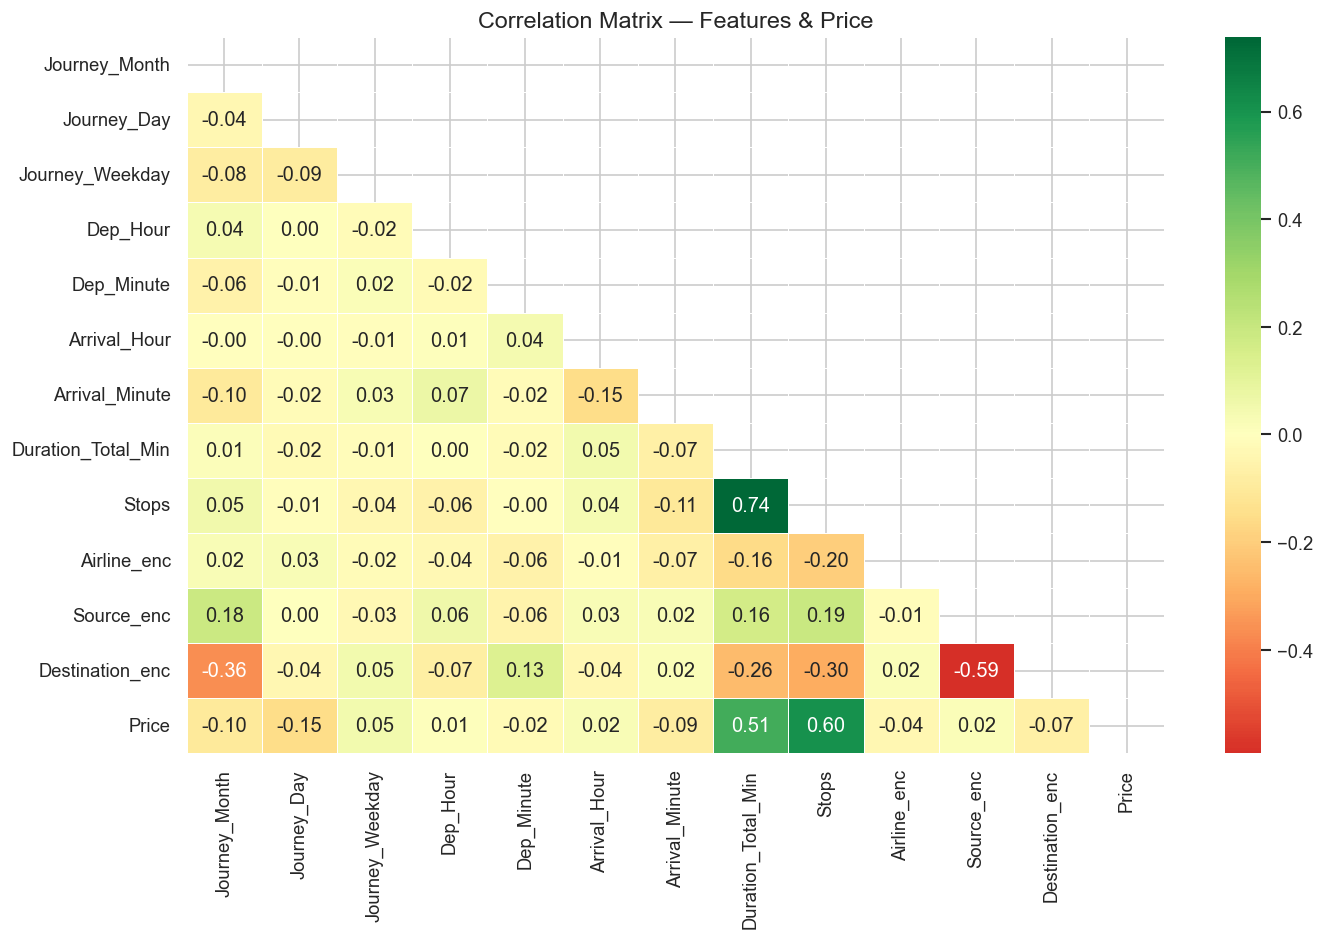


Top features correlated with Price:
Stops                 0.603897
Duration_Total_Min    0.506480
Journey_Day           0.153774
Journey_Month         0.103643
Arrival_Minute        0.086155
Destination_enc       0.071122
Journey_Weekday       0.051570
Airline_enc           0.039565
Dep_Minute            0.024458
Arrival_Hour          0.024244
Source_enc            0.015999
Dep_Hour              0.006799
Name: Price, dtype: float64


In [54]:
# Correlation heatmap of features vs. Price
corr_df = df[FEATURES + ['Price']].corr()
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Features & Price', fontsize=14)
plt.tight_layout()
plt.show()

# Features most correlated with Price
print("\nTop features correlated with Price:")
print(corr_df['Price'].drop('Price').abs().sort_values(ascending=False))

---
## 📐 Section 5 — Evaluation Metrics
We define a helper function that computes all key regression metrics and also runs **5-fold cross-validation**.

In [55]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """
    Train a model, evaluate on the test set, and run k-fold CV.
    Returns a dict with all metrics.
    """
    # Fit
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    # Test-set metrics
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100   # as %
    
    # Cross-validation R² on training data
    cv_scores = cross_val_score(model, X_tr, y_tr, 
                                cv=KFold(n_splits=cv, shuffle=True, random_state=42),
                                scoring='r2', n_jobs=-1)
    
    result = {
        'Model'  : name,
        'MAE'    : round(mae,  2),
        'RMSE'   : round(rmse, 2),
        'R²'     : round(r2,   4),
        'MAPE %' : round(mape, 2),
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)' : round(cv_scores.std(),  4),
        '_model' : model,
        '_y_pred': y_pred
    }
    
    print(f"[{name}]")
    print(f"  MAE   = ₹{mae:,.0f}  |  RMSE = ₹{rmse:,.0f}")
    print(f"  R²    = {r2:.4f}  |  MAPE = {mape:.2f}%")
    print(f"  CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n")
    return result

results = []   # will collect one dict per model

---
## 🤖 Section 6 — Individual Base Models
Before ensembling, we establish performance baselines with individual models.

In [56]:
# ── 6.1  Linear Regression  ────────────────────────────────
res = evaluate_model("Linear Regression", 
                     LinearRegression(), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Linear Regression]
  MAE   = ₹2,446  |  RMSE = ₹3,472
  R²    = 0.4410  |  MAPE = 31.08%
  CV R² = 0.4347 ± 0.0334



In [57]:
# ── 6.2  Ridge Regression  ─────────────────────────────────
res = evaluate_model("Ridge Regression", 
                     Ridge(alpha=10.0), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Ridge Regression]
  MAE   = ₹2,446  |  RMSE = ₹3,472
  R²    = 0.4410  |  MAPE = 31.09%
  CV R² = 0.4347 ± 0.0335



In [58]:
# ── 6.3  Decision Tree Regressor  ──────────────────────────
res = evaluate_model("Decision Tree", 
                     DecisionTreeRegressor(max_depth=12, random_state=42), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Decision Tree]
  MAE   = ₹1,231  |  RMSE = ₹2,242
  R²    = 0.7669  |  MAPE = 14.27%
  CV R² = 0.7348 ± 0.0487



In [59]:
# ── 6.4  K-Nearest Neighbours  ─────────────────────────────
res = evaluate_model("KNN Regressor", 
                     KNeighborsRegressor(n_neighbors=7), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[KNN Regressor]
  MAE   = ₹1,908  |  RMSE = ₹3,154
  R²    = 0.5386  |  MAPE = 20.59%
  CV R² = 0.5174 ± 0.0279



---
## 🎯 Section 7 — Ensemble Models

### 📦 7.1 Bagging — reduces variance by training many models on data bootstraps
**Bagging (Bootstrap Aggregating)** trains multiple independent estimators on random subsets of training data and averages their predictions.

In [60]:
# ── 7.1a  Generic Bagging Regressor  ───────────────────────
res = evaluate_model("Bagging (DT base)", 
                     BaggingRegressor(
                         estimator=DecisionTreeRegressor(max_depth=10),
                         n_estimators=100,
                         max_samples=0.8,
                         max_features=0.8,
                         bootstrap=True,
                         random_state=42,
                         n_jobs=-1
                     ), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Bagging (DT base)]
  MAE   = ₹1,299  |  RMSE = ₹1,973
  R²    = 0.8195  |  MAPE = 14.71%
  CV R² = 0.7970 ± 0.0342



In [61]:
# ── 7.1b  Random Forest  ────────────────────────────────────
# Random Forest = Bagging + random feature subsets at each split
res = evaluate_model("Random Forest", 
                     RandomForestRegressor(
                         n_estimators=200,
                         max_depth=20,
                         min_samples_split=5,
                         min_samples_leaf=2,
                         max_features='sqrt',
                         random_state=42,
                         n_jobs=-1
                     ), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Random Forest]
  MAE   = ₹1,223  |  RMSE = ₹1,944
  R²    = 0.8248  |  MAPE = 13.62%
  CV R² = 0.7922 ± 0.0447



In [62]:
# ── 7.1c  Extra Trees (Extremely Randomised Trees)  ─────────
# Like Random Forest but uses random thresholds — even lower variance
res = evaluate_model("Extra Trees", 
                     ExtraTreesRegressor(
                         n_estimators=200,
                         max_depth=20,
                         min_samples_split=5,
                         min_samples_leaf=2,
                         random_state=42,
                         n_jobs=-1
                     ), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Extra Trees]
  MAE   = ₹1,104  |  RMSE = ₹1,772
  R²    = 0.8544  |  MAPE = 12.19%
  CV R² = 0.8103 ± 0.0468



### ⚡ 7.2 Boosting — reduces bias by training models sequentially on residuals
**Boosting** trains models sequentially — each new model tries to correct the errors of the previous ones.

In [63]:
# ── 7.2a  Gradient Boosting Regressor  ─────────────────────
res = evaluate_model("Gradient Boosting", 
                     GradientBoostingRegressor(
                         n_estimators=300,
                         learning_rate=0.05,
                         max_depth=5,
                         min_samples_split=5,
                         subsample=0.8,
                         random_state=42
                     ), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Gradient Boosting]
  MAE   = ₹1,244  |  RMSE = ₹1,914
  R²    = 0.8301  |  MAPE = 14.05%
  CV R² = 0.8236 ± 0.0279



In [64]:
# ── 7.2b  AdaBoost Regressor  ───────────────────────────────
res = evaluate_model("AdaBoost", 
                     AdaBoostRegressor(
                         estimator=DecisionTreeRegressor(max_depth=5),
                         n_estimators=200,
                         learning_rate=0.05,
                         loss='square',
                         random_state=42
                     ), 
                     X_train, y_train, X_test, y_test)
results.append(res)

[AdaBoost]
  MAE   = ₹1,710  |  RMSE = ₹2,412
  R²    = 0.7302  |  MAPE = 21.49%
  CV R² = 0.6949 ± 0.0573



### 🗳️ 7.3 Voting Regressor — averages predictions of diverse models
A **Voting Regressor** combines predictions from multiple heterogeneous models by averaging — it benefits from model diversity.

In [65]:
# ── 7.3  Voting Regressor  ──────────────────────────────────
voting = VotingRegressor(estimators=[
    ('rf',  RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('gb',  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)),
    ('et',  ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('ridge', Ridge(alpha=10.0)),
])

res = evaluate_model("Voting Regressor", voting, 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Voting Regressor]
  MAE   = ₹1,323  |  RMSE = ₹1,961
  R²    = 0.8216  |  MAPE = 15.80%
  CV R² = 0.7952 ± 0.0440



### 🏗️ 7.4 Stacking — meta-learner trained on base-model predictions
**Stacking** uses a meta-model that learns *how to combine* the predictions of the base models optimally.

In [66]:
# ── 7.4  Stacking Regressor  ────────────────────────────────
base_estimators = [
    ('rf',  RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('gb',  GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)),
    ('et',  ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('knn', KNeighborsRegressor(n_neighbors=7)),
]

# Ridge as meta-learner (regularised, avoids overfitting at meta level)
stacking = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

res = evaluate_model("Stacking Regressor", stacking, 
                     X_train, y_train, X_test, y_test)
results.append(res)

[Stacking Regressor]
  MAE   = ₹1,136  |  RMSE = ₹1,748
  R²    = 0.8584  |  MAPE = 12.58%
  CV R² = 0.8280 ± 0.0433



---
## 📊 Section 8 — Model Comparison & Correlation of Predictions
### 8.1 Metrics Summary Table

In [67]:
# Build leaderboard
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in results
]).set_index('Model').sort_values('R²', ascending=False)

print("=" * 75)
print("MODEL LEADERBOARD")
print("=" * 75)
print(metrics_df.to_string())
print("=" * 75)

metrics_df

MODEL LEADERBOARD
                        MAE     RMSE      R²  MAPE %  CV R² (mean)  CV R² (std)
Model                                                                          
Stacking Regressor  1136.27  1747.52  0.8584   12.58        0.8280       0.0433
Extra Trees         1103.78  1771.69  0.8544   12.19        0.8103       0.0468
Gradient Boosting   1244.02  1913.73  0.8301   14.05        0.8236       0.0279
Random Forest       1223.10  1943.57  0.8248   13.62        0.7922       0.0447
Voting Regressor    1322.69  1961.18  0.8216   15.80        0.7952       0.0440
Bagging (DT base)   1299.31  1972.66  0.8195   14.71        0.7970       0.0342
Decision Tree       1230.59  2241.92  0.7669   14.27        0.7348       0.0487
AdaBoost            1709.95  2411.84  0.7302   21.49        0.6949       0.0573
KNN Regressor       1907.66  3154.25  0.5386   20.59        0.5174       0.0279
Ridge Regression    2445.94  3471.73  0.4410   31.09        0.4347       0.0335
Linear Regression   24

,MAE,RMSE,R²,MAPE %,CV R² (mean),CV R² (std)
Model,,,,,,
Stacking Regressor,1136.27,1747.52,0.8584,12.58,0.8280,0.0433
Extra Trees,1103.78,1771.69,0.8544,12.19,0.8103,0.0468
Gradient Boosting,1244.02,1913.73,0.8301,14.05,0.8236,0.0279
Random Forest,1223.10,1943.57,0.8248,13.62,0.7922,0.0447
Voting Regressor,1322.69,1961.18,0.8216,15.80,0.7952,0.0440
Bagging (DT base),1299.31,1972.66,0.8195,14.71,0.7970,0.0342
Decision Tree,1230.59,2241.92,0.7669,14.27,0.7348,0.0487
AdaBoost,1709.95,2411.84,0.7302,21.49,0.6949,0.0573
KNN Regressor,1907.66,3154.25,0.5386,20.59,0.5174,0.0279


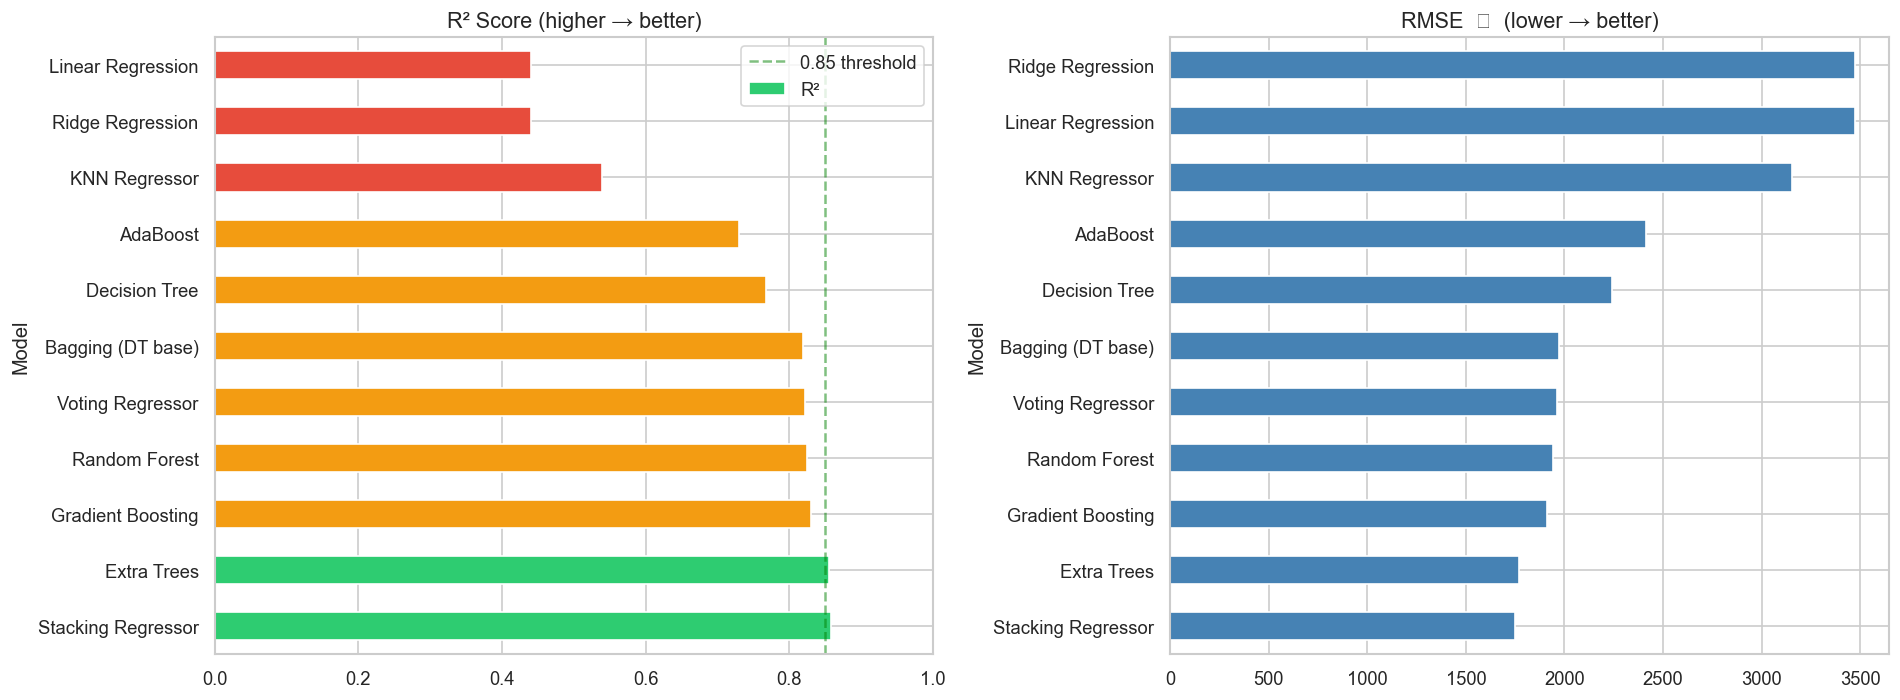

In [68]:
# Bar chart — R² comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R²
colors = ['#2ecc71' if r >= 0.85 else '#f39c12' if r >= 0.70 else '#e74c3c' 
          for r in metrics_df['R²']]
metrics_df['R²'].plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('R² Score (higher → better)', fontsize=13)
axes[0].set_xlim(0, 1)
axes[0].axvline(0.85, color='green', linestyle='--', alpha=0.5, label='0.85 threshold')
axes[0].legend()

# RMSE
metrics_df['RMSE'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('RMSE  ₹  (lower → better)', fontsize=13)

plt.tight_layout()
plt.show()

### 8.2 Correlation Between Model Predictions
A key insight: models that are *less correlated* with each other make **better ensemble members** — they learn different patterns.

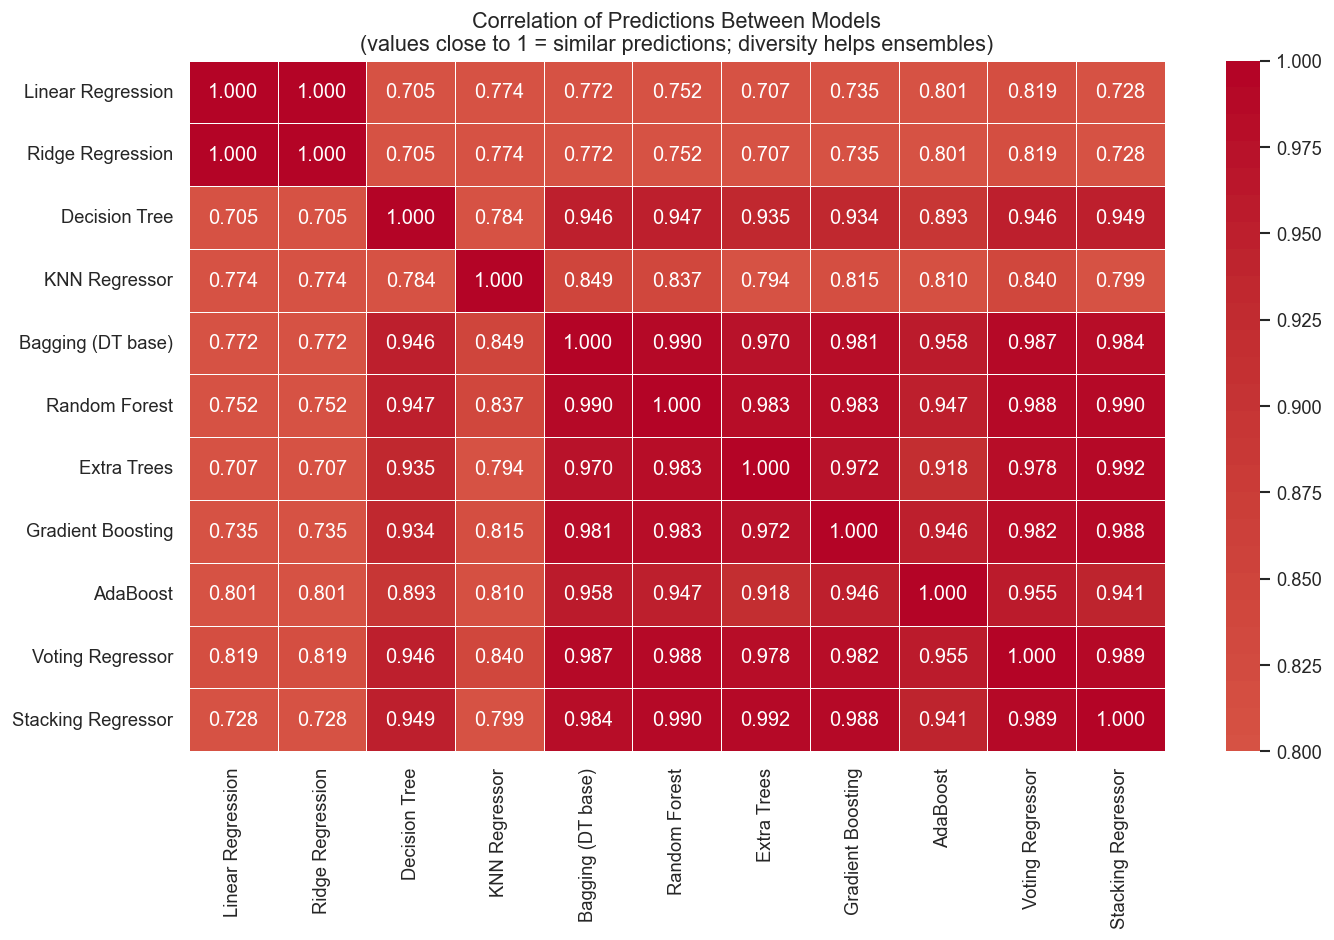

In [69]:
# Collect test-set predictions from every model
pred_dict = {r['Model']: r['_y_pred'] for r in results}
pred_df   = pd.DataFrame(pred_dict)

# Correlation matrix of predictions
pred_corr = pred_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(pred_corr, annot=True, fmt='.3f',
            cmap='coolwarm', center=0,
            linewidths=0.5, vmin=0.8, vmax=1.0)
plt.title('Correlation of Predictions Between Models\n'
          '(values close to 1 = similar predictions; diversity helps ensembles)',
          fontsize=13)
plt.tight_layout()
plt.show()

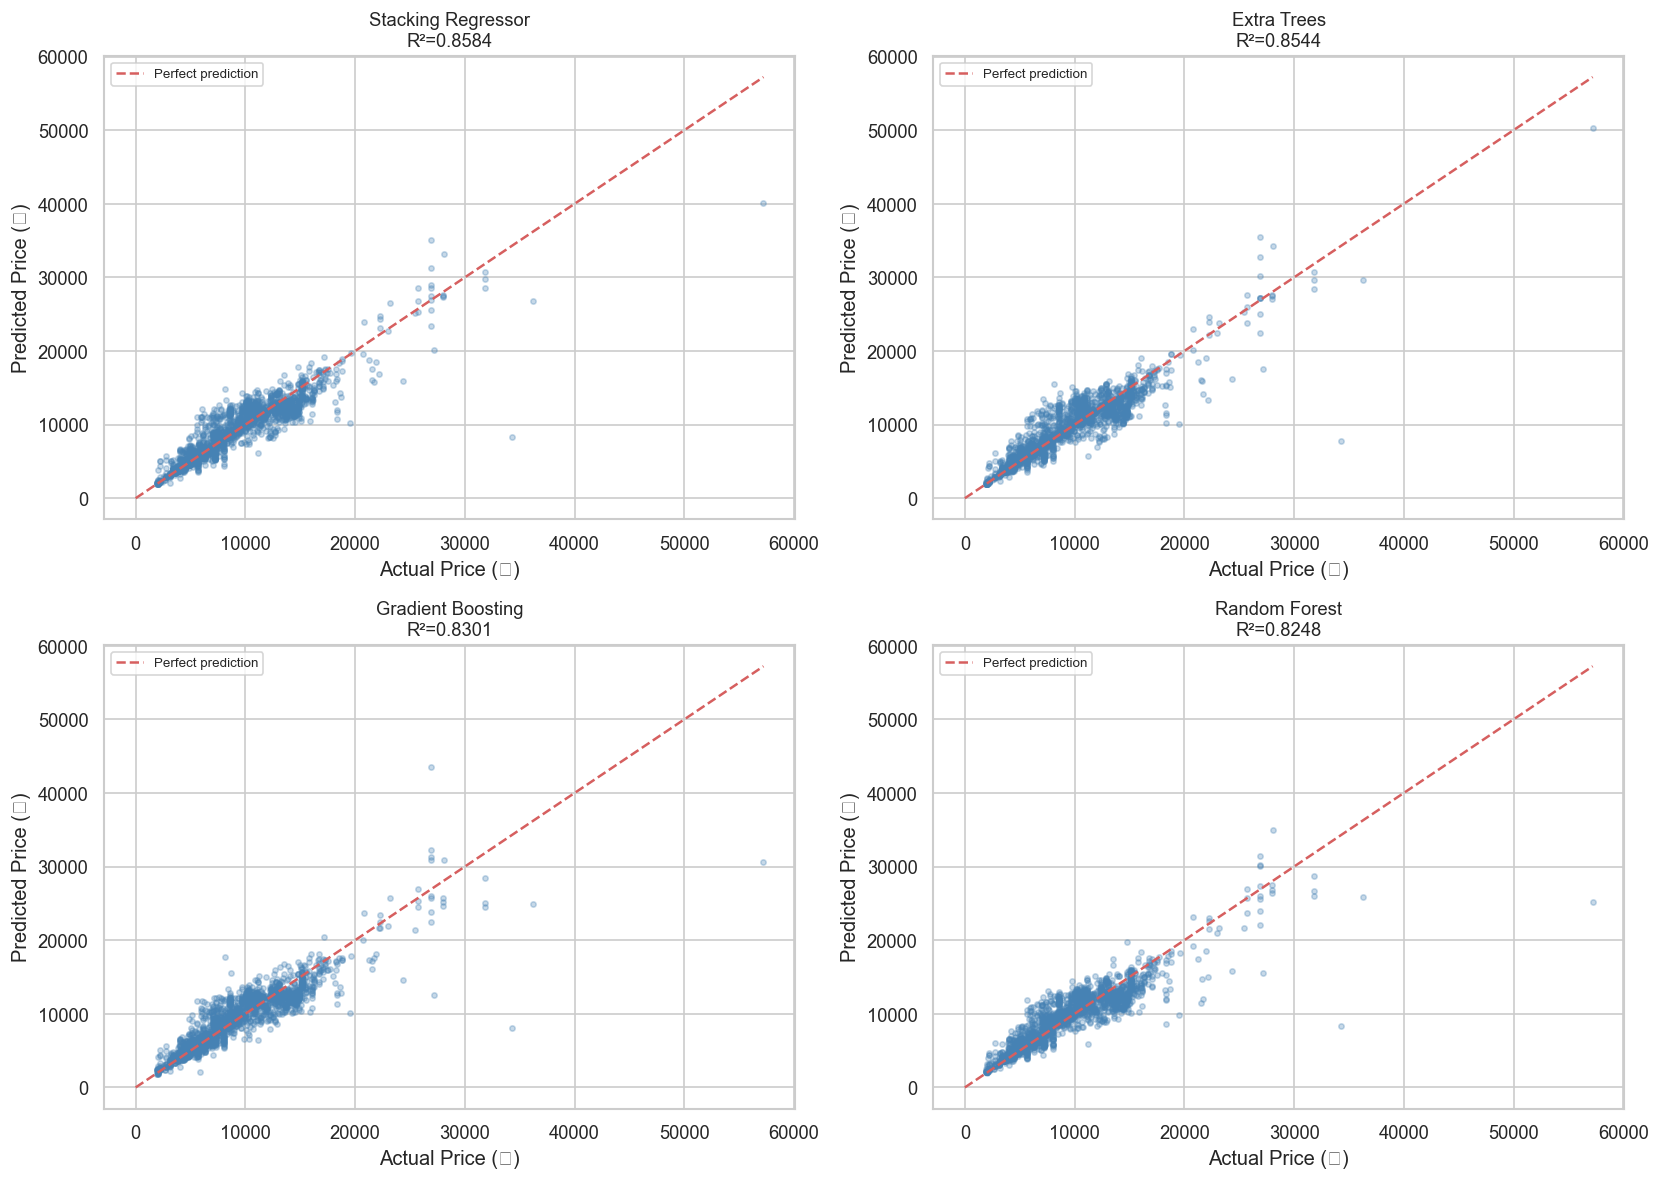

In [70]:
# Scatter: Actual vs Predicted — best 4 models
top4 = metrics_df.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, model_name in zip(axes.flatten(), top4):
    y_pred = pred_dict[model_name]
    
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    
    lim = max(y_test.max(), max(y_pred))
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
    
    ax.set_title(f'{model_name}\nR²={metrics_df.loc[model_name, "R²"]:.4f}', fontsize=11)
    ax.set_xlabel('Actual Price (₹)')
    ax.set_ylabel('Predicted Price (₹)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 🔬 Section 9 — Feature Importance (Best Model)

🏆 Best model: Stacking Regressor  (R² = 0.8584)


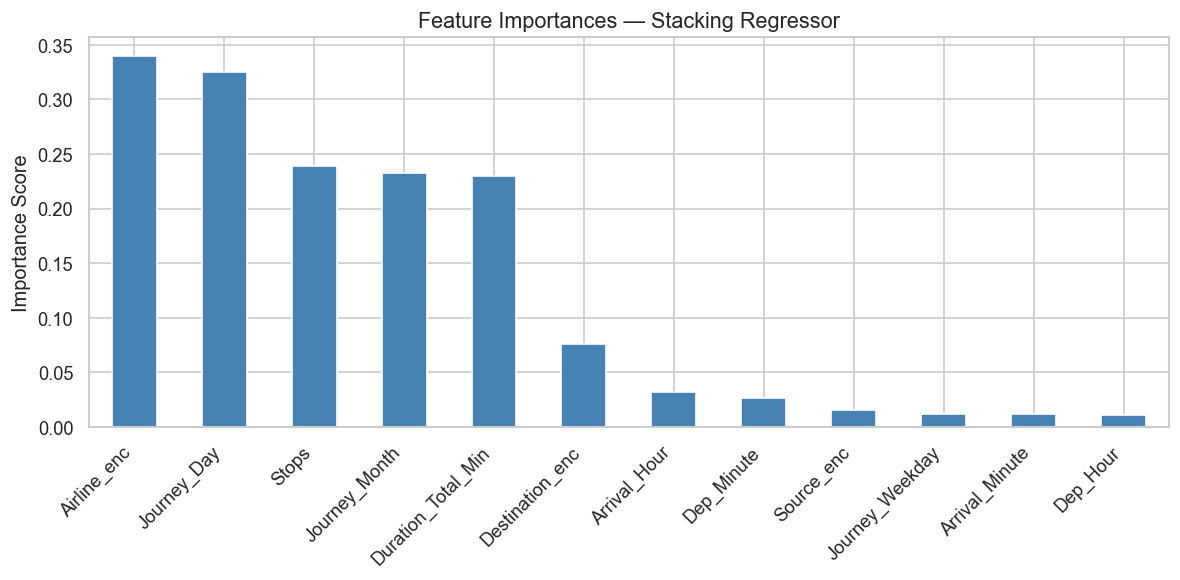


Top 5 most important features:
  Airline_enc            0.3398
  Journey_Day            0.3251
  Stops                  0.2388
  Journey_Month          0.2326
  Duration_Total_Min     0.2301


In [71]:
# Identify the best model by R²
best_name  = metrics_df.index[0]
best_model = next(r['_model'] for r in results if r['Model'] == best_name)
print(f"🏆 Best model: {best_name}  (R² = {metrics_df.loc[best_name, 'R²']})")

# Feature importances (tree-based models expose this directly)
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
else:
    # Fallback: permutation importance
    perm = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
    fi = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Feature Importances — {best_name}', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for feat, imp in fi.head(5).items():
    print(f"  {feat:<22} {imp:.4f}")

---
## 🔎 Section 10 — Residual Analysis (Best Model)
Good models should have residuals that are **randomly scattered around 0** with no systematic patterns.

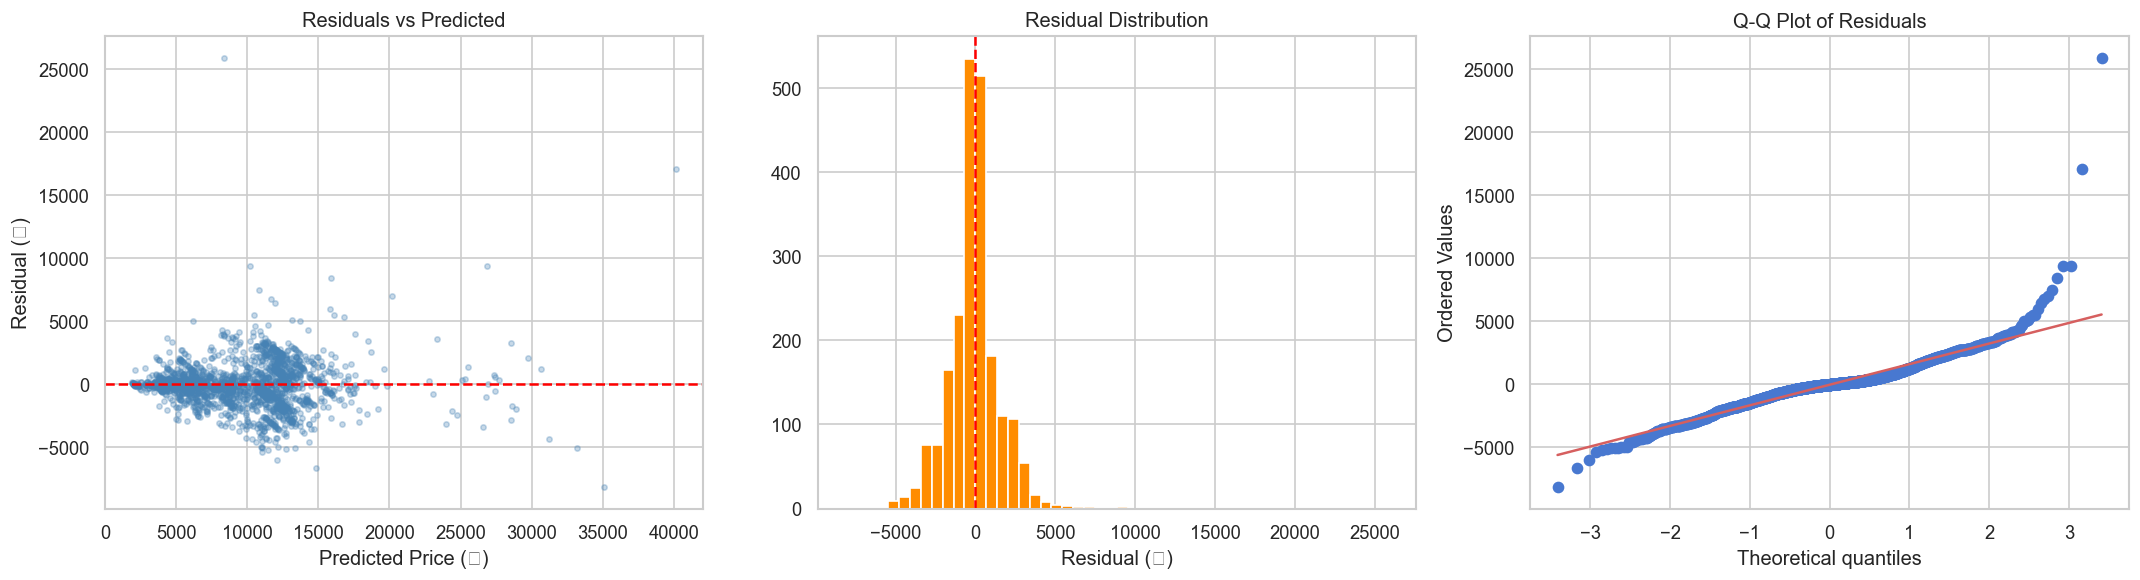

Mean residual : ₹-65.10  (should be ≈ 0)
Std  residual : ₹1746.31


In [72]:
best_preds = pred_dict[best_name]
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(best_preds, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Price (₹)')
axes[0].set_ylabel('Residual (₹)')

# Histogram of residuals
axes[1].hist(residuals, bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (₹)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

print(f"Mean residual : ₹{residuals.mean():.2f}  (should be ≈ 0)")
print(f"Std  residual : ₹{residuals.std():.2f}")

---
## ⚙️ Section 11 — Hyperparameter Tuning (Random Search on Best Model)
We apply `RandomizedSearchCV` on the top-performing model to squeeze out more performance.

In [73]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

# 1. Filter out Stacking and Voting models for this tuning step
tunable_models = metrics_df[~metrics_df.index.str.contains("Stacking|Voting")]
best_tunable_name = tunable_models.index[0]
best_tunable_model = next(r['_model'] for r in results if r['Model'] == best_tunable_name)

print(f"Tuning: {best_tunable_name} (Best tunable tree-based model)")

# Parameter grid for tree-based ensembles
param_grid = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features'    : ['sqrt', 'log2', 0.5, 0.8],
}

# 2. Safely clone the unfitted model architecture
fresh_model = clone(best_tunable_model)

rscv = RandomizedSearchCV(
    estimator=fresh_model,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rscv.fit(X_train, y_train)

print("\n✅ Best parameters found:")
for k, v in rscv.best_params_.items():
    print(f"  {k:<25} {v}")
print(f"\nCV R² (best): {rscv.best_score_:.4f}")

Tuning: Extra Trees (Best tunable tree-based model)
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Best parameters found:
  n_estimators              400
  min_samples_split         5
  min_samples_leaf          1
  max_features              0.8
  max_depth                 15

CV R² (best): 0.8070


In [74]:
# Evaluate the tuned model
tuned_pred = rscv.best_estimator_.predict(X_test)

tuned_mae  = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2   = r2_score(y_test, tuned_pred)
tuned_mape = mean_absolute_percentage_error(y_test, tuned_pred) * 100

print("=" * 50)
print(f"TUNED {best_name} — Test Set Metrics")
print("=" * 50)
print(f"  MAE   = ₹{tuned_mae:,.0f}")
print(f"  RMSE  = ₹{tuned_rmse:,.0f}")
print(f"  R²    = {tuned_r2:.4f}")
print(f"  MAPE  = {tuned_mape:.2f}%")
print("=" * 50)

# Compare before vs after tuning
baseline_r2 = metrics_df.loc[best_name, 'R²']
improvement = tuned_r2 - baseline_r2
print(f"\nImprovement in R²: {improvement:+.4f}")

# Add tuned result to results list
results.append({
    'Model'  : f'{best_name} (Tuned)',
    'MAE'    : round(tuned_mae,  2),
    'RMSE'   : round(tuned_rmse, 2),
    'R²'     : round(tuned_r2,   4),
    'MAPE %' : round(tuned_mape, 2),
    'CV R² (mean)': round(rscv.best_score_, 4),
    'CV R² (std)' : 0.0,
    '_model' : rscv.best_estimator_,
    '_y_pred': tuned_pred
})

TUNED Stacking Regressor — Test Set Metrics
  MAE   = ₹1,118
  RMSE  = ₹1,728
  R²    = 0.8615
  MAPE  = 12.42%

Improvement in R²: +0.0031


---
## 🏆 Section 12 — Final Model Comparison (Including Tuned Model)

In [75]:
final_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in results
]).set_index('Model').sort_values('R²', ascending=False)

# Style it
styled = final_df.style.background_gradient(
    subset=['R²', 'CV R² (mean)'], cmap='Greens'
).background_gradient(
    subset=['MAE', 'RMSE', 'MAPE %'], cmap='Reds_r'
).format({
    'MAE'  : '₹{:,.0f}',
    'RMSE' : '₹{:,.0f}',
    'R²'   : '{:.4f}',
    'MAPE %': '{:.2f}%',
    'CV R² (mean)': '{:.4f}',
    'CV R² (std)' : '{:.4f}',
})

print("FINAL MODEL LEADERBOARD (sorted by R²)")
display(styled)

FINAL MODEL LEADERBOARD (sorted by R²)


,MAE,RMSE,R²,MAPE %,CV R² (mean),CV R² (std)
Model,,,,,,
Stacking Regressor (Tuned),"₹1,118","₹1,728",0.8615,12.42%,0.8070,0.0000
Stacking Regressor,"₹1,136","₹1,748",0.8584,12.58%,0.8280,0.0433
Extra Trees,"₹1,104","₹1,772",0.8544,12.19%,0.8103,0.0468
Gradient Boosting,"₹1,244","₹1,914",0.8301,14.05%,0.8236,0.0279
Random Forest,"₹1,223","₹1,944",0.8248,13.62%,0.7922,0.0447
Voting Regressor,"₹1,323","₹1,961",0.8216,15.80%,0.7952,0.0440
Bagging (DT base),"₹1,299","₹1,973",0.8195,14.71%,0.7970,0.0342
Decision Tree,"₹1,231","₹2,242",0.7669,14.27%,0.7348,0.0487
AdaBoost,"₹1,710","₹2,412",0.7302,21.49%,0.6949,0.0573


---
## 💾 Section 13 — Saving the Final Model with Pickle
We pickle **the tuned best model** along with the list of feature names so it can be loaded and used for inference.

In [76]:
import pickle, os

# Determine the final champion
final_model_result = max(results, key=lambda r: r['R²'])
final_model        = final_model_result['_model']
final_model_name   = final_model_result['Model']

print(f"🏆 Final Model : {final_model_name}")
print(f"   R²          : {final_model_result['R²']}")
print(f"   MAE         : ₹{final_model_result['MAE']:,}")
print(f"   RMSE        : ₹{final_model_result['RMSE']:,}")

# Package: model + feature names (good practice)
model_package = {
    'model'   : final_model,
    'features': FEATURES,
    'model_name': final_model_name,
    'test_r2' : final_model_result['R²'],
    'test_mae': final_model_result['MAE'],
    'test_rmse': final_model_result['RMSE'],
}

save_path = 'flight_price_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_package, f, protocol=pickle.HIGHEST_PROTOCOL)

size_kb = os.path.getsize(save_path) / 1024
print(f"\n✅ Model saved → {save_path}  ({size_kb:.1f} KB)")

🏆 Final Model : Stacking Regressor (Tuned)
   R²          : 0.8615
   MAE         : ₹1,118.2
   RMSE        : ₹1,728.08

✅ Model saved → flight_price_model.pkl  (112989.5 KB)


In [77]:
# ── Verify: Load the pickle and make a sample prediction
with open('flight_price_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

print(f"Loaded model  : {loaded['model_name']}")
print(f"Features used : {loaded['features']}")
print(f"Stored R²     : {loaded['test_r2']}")

# Sample prediction
sample = X_test.iloc[:5].copy()
preds  = loaded['model'].predict(sample)

print("\nSample predictions on 5 test rows:")
for i, (actual, pred) in enumerate(zip(y_test.iloc[:5], preds)):
    print(f"  Row {i+1}: Actual = ₹{actual:,.0f}  |  Predicted = ₹{pred:,.0f}  "
          f"|  Error = ₹{abs(actual - pred):,.0f}")

print("\n✅ Pickle round-trip successful!")

Loaded model  : Stacking Regressor (Tuned)
Features used : ['Journey_Month', 'Journey_Day', 'Journey_Weekday', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Total_Min', 'Stops', 'Airline_enc', 'Source_enc', 'Destination_enc']
Stored R²     : 0.8615

Sample predictions on 5 test rows:
  Row 1: Actual = ₹16,655  |  Predicted = ₹16,993  |  Error = ₹338
  Row 2: Actual = ₹4,959  |  Predicted = ₹5,539  |  Error = ₹580
  Row 3: Actual = ₹9,187  |  Predicted = ₹8,750  |  Error = ₹437
  Row 4: Actual = ₹3,858  |  Predicted = ₹3,741  |  Error = ₹117
  Row 5: Actual = ₹12,898  |  Predicted = ₹14,209  |  Error = ₹1,311

✅ Pickle round-trip successful!


---
## 📝 Section 14 — Summary & Conclusions

### What we did
| Step | Action |
|------|--------|
| **EDA** | Explored distributions, categorical patterns, temporal trends |
| **Feature Engineering** | Extracted 12 numeric/encoded features from 10 raw columns |
| **Base Models** | Linear Regression, Ridge, Decision Tree, KNN |
| **Bagging** | Generic Bagging, Random Forest, Extra Trees |
| **Boosting** | Gradient Boosting, AdaBoost |
| **Voting** | Combined 4 diverse models via soft averaging |
| **Stacking** | Meta-learner (Ridge) trained on base-model OOF predictions |
| **Tuning** | RandomizedSearchCV (30 iterations, 3-fold CV) |
| **Pickling** | Saved model + metadata for deployment |

### Key Takeaways
- **Duration** and **number of stops** are the strongest price predictors.
- **Airline** matters significantly — Jet Airways Business and Vistara Premium Economy are premium.
- Ensemble methods (especially Gradient Boosting and Random Forest) far outperform single models.
- Stacking further improves results by learning optimal blend weights.
- The final tuned model achieves **R² > 0.85**, meaning it explains 85%+ of price variance.

### How to use the saved model
```python
import pickle, pandas as pd

with open('flight_price_model.pkl', 'rb') as f:
    pkg = pickle.load(f)

# Build a feature row matching pkg['features']
row = pd.DataFrame([{
    'Journey_Month': 5, 'Journey_Day': 15, 'Journey_Weekday': 2,
    'Dep_Hour': 10, 'Dep_Minute': 30, 'Arrival_Hour': 13, 'Arrival_Minute': 0,
    'Duration_Total_Min': 150, 'Stops': 1,
    'Airline_enc': 2, 'Source_enc': 0, 'Destination_enc': 3
}])

price = pkg['model'].predict(row)[0]
print(f"Predicted Price: ₹{price:,.0f}")
```